# Fabricación de evidencia: cuando los argumentos superan los hechos
### El Evidence Gap Index (EGI) como detector de ciclos retóricos fabricados — Iraq 2003 e Irán 2026

El Evidence Gap Index (EGI) mide la diferencia entre la intensidad de las afirmaciones públicas sobre una amenaza y la evidencia verificable que las respalda. Cuando EGI supera 0.35 de forma sostenida durante 30 o más días, la brecha entre narrativa y evidencia es suficientemente severa como para constituir una señal de fabricación.

> **Fuente de datos y metodología EGI** (configurable con `USE_REAL_GDELT`):
>
> - **`False` — Mock parquet v3:** El EGI viene pre-calculado para los cinco casos. Reproducible sin conexión. Útil para ilustrar el modelo teórico.
> - **`True` — GDELT real + proxy CAMEO:** Se descarga GDELT para los casos con cobertura disponible. El EGI se estima como proxy: `evidence_score` = fracción de eventos con códigos CAMEO materiales/verificables (04–20) respecto al total; `evidence_gap` = `narrative_intensity − evidence_score`. Los casos sin cobertura GDELT usan fallback a mock.
>
> **Importante:** El proxy CAMEO es una aproximación. El EGI teórico requiere cruzar GDELT con fuentes externas (informes IAEA, resoluciones ONU, documentos desclasificados). Los resultados con datos reales difieren del mock y esa diferencia es en sí misma un hallazgo metodológico.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch

plt.style.use('seaborn-v0_8-whitegrid')

# ── Fuente de datos ───────────────────────────────────────────────────────────
USE_REAL_GDELT = True  # True = proxy EGI desde GDELT real | False = mock parquet local

CASES = {
    'gulf_1991':        {'label': 'Golfo 1991',       'color': '#378ADD', 'tipo': 'Construcción'},
    'afghanistan_2001': {'label': 'Afganistán 2001',  'color': '#1D9E75', 'tipo': 'Redirección'},
    'iraq_2003':        {'label': 'Irak 2003',         'color': '#BA7517', 'tipo': 'Fabricación'},
    'libya_2011':       {'label': 'Libia 2011',        'color': '#7F77DD', 'tipo': 'Construcción'},
    'iran_2026':        {'label': 'Irán 2026',         'color': '#E24B4A', 'tipo': 'Fabricación'},
}

# Códigos CAMEO materiales/verificables (vs. retóricos 01-03, 10-13)
_MATERIAL_CODES = {4, 5, 6, 7, 8, 9, 14, 15, 16, 17, 18, 19, 20}

if USE_REAL_GDELT:
    import gdelt as gdelt_pkg

    _GDELT_V2_START = pd.Timestamp('2015-02-19')
    _INVASION_DATES = {
        'gulf_1991': '1991-01-17', 'afghanistan_2001': '2001-10-07',
        'iraq_2003': '2003-03-20', 'libya_2011':       '2011-03-19', 'iran_2026': '2026-02-28',
    }
    _CASE_COUNTRY = {
        'gulf_1991': 'IRQ', 'afghanistan_2001': 'AFG',
        'iraq_2003': 'IRQ', 'libya_2011':       'LBA', 'iran_2026': 'IRN',
    }

    def _assign_phase(d):
        if d > 45:  return 'construccion_enemigo'
        elif d > 14: return 'justificacion_moral'
        elif d > 3:  return 'manufactura_consenso'
        else:        return 'escalamiento'

    def _fetch_case_egi(case_name, inv_str, country_code):
        invasion = pd.Timestamp(inv_str)
        start    = invasion - pd.Timedelta(days=180)
        is_v2    = start >= _GDELT_V2_START
        gd       = gdelt_pkg.gdelt(version=2 if is_v2 else 1)
        dates    = pd.date_range(start=start, end=invasion, freq='D' if is_v2 else 'W')
        raw      = gd.Search([d.strftime('%Y %m %d') for d in dates],
                             table='events', coverage=False, output='df')
        filt = raw[(raw['Actor1CountryCode'] == country_code) |
                   (raw['Actor2CountryCode'] == country_code)].copy()
        filt['date'] = pd.to_datetime(filt['SQLDATE'].astype(str), format='%Y%m%d')
        # EGI proxy: evidence_score = fracción de eventos con código CAMEO material
        filt['parent_code'] = pd.to_numeric(
            filt['EventCode'].astype(str).str.zfill(3).str[:2], errors='coerce'
        ).fillna(0).astype(int)
        filt['is_material'] = filt['parent_code'].isin(_MATERIAL_CODES)
        daily = filt.groupby('date').agg(
            NumArticles=('NumArticles', 'sum'),
            AvgTone=('AvgTone', 'mean'),
            total_events=('EventCode', 'count'),
            material_events=('is_material', 'sum'),
        ).reset_index()
        vols = daily['NumArticles'].values.astype(float)
        daily['narrative_intensity'] = vols / max(vols.max(), 1.0)
        daily['evidence_score'] = daily['material_events'] / daily['total_events'].clip(lower=1)
        daily['evidence_gap']   = (daily['narrative_intensity'] - daily['evidence_score']).clip(lower=0)
        days_before = [(invasion - d).days for d in daily['date']]
        daily['case']                = case_name
        daily['days_before_invasion']= [abs(d) for d in days_before]
        daily['phase']               = [_assign_phase(abs(d)) for d in days_before]
        return daily

    all_dfs = []
    _sources = {}
    for case_name, inv_str in _INVASION_DATES.items():
        print(f'  → {case_name}... ', end='', flush=True)
        try:
            all_dfs.append(_fetch_case_egi(case_name, inv_str, _CASE_COUNTRY[case_name]))
            _sources[case_name] = 'REAL'
            print('✓ REAL (proxy EGI)')
        except Exception as e:
            print(f'error — usando mock')
            mock = pd.read_parquet('../data/gdelt_mock_v3.parquet')
            all_dfs.append(mock[mock['case'] == case_name].copy())
            _sources[case_name] = 'MOCK'

    df = pd.concat(all_dfs, ignore_index=True)
    _source_label = '🌐 GDELT real con proxy EGI (CAMEO) + fallback mock'
else:
    df = pd.read_parquet('../data/gdelt_mock_v3.parquet')
    _sources = {k: 'MOCK' for k in CASES}
    _source_label = '📦 Mock parquet v3 (EGI pre-calculado — modelo teórico)'

df['days_before_invasion'] = df['days_before_invasion'].abs()
df['date'] = pd.to_datetime(df['date'])

print(f'\nFuente: {_source_label}')
print(f'Datos:  {len(df):,} eventos · {df["case"].nunique()} casos · {df["date"].dt.year.min()}–{df["date"].dt.year.max()}')
print(f'Cobertura: { {k: v for k, v in _sources.items()} }')

  → gulf_1991... here
here
✓ REAL (proxy EGI)
  → afghanistan_2001... here
✓ REAL (proxy EGI)
  → iraq_2003... here
here
✓ REAL (proxy EGI)
  → libya_2011... here
here
here
herehere

here
here
error — usando mock
  → iran_2026... here
here
here
here
here
here
here
here
herehere

here
here
✓ REAL (proxy EGI)

Fuente: 🌐 GDELT real con proxy EGI (CAMEO) + fallback mock
Datos:  2,270 eventos · 5 casos · 1990–2026
Cobertura: {'gulf_1991': 'REAL', 'afghanistan_2001': 'REAL', 'iraq_2003': 'REAL', 'libya_2011': 'MOCK', 'iran_2026': 'REAL'}


## 1. El Evidence Gap Index (EGI)

El EGI se define como:

$$\text{EGI}(t) = \text{claim\_intensity}(t) - \text{evidence\_score}(t)$$

En la práctica, se calcula como la diferencia entre la intensidad narrativa de las afirmaciones sobre la amenaza y la densidad de evidencia verificable que las respalda. Valores positivos indican que la retórica supera a la evidencia; valores negativos o cercanos a cero indican coherencia entre afirmaciones y hechos.

**Criterio de fabricación:** EGI > 0.35 sostenido durante 30 o más días consecutivos.

| EGI | Interpretación |
|-----|----------------|
| < 0.10 | Afirmaciones respaldadas por evidencia |
| 0.10 – 0.35 | Brecha moderada, normal en cobertura bélica |
| > 0.35 | Brecha severa — posible fabricación |

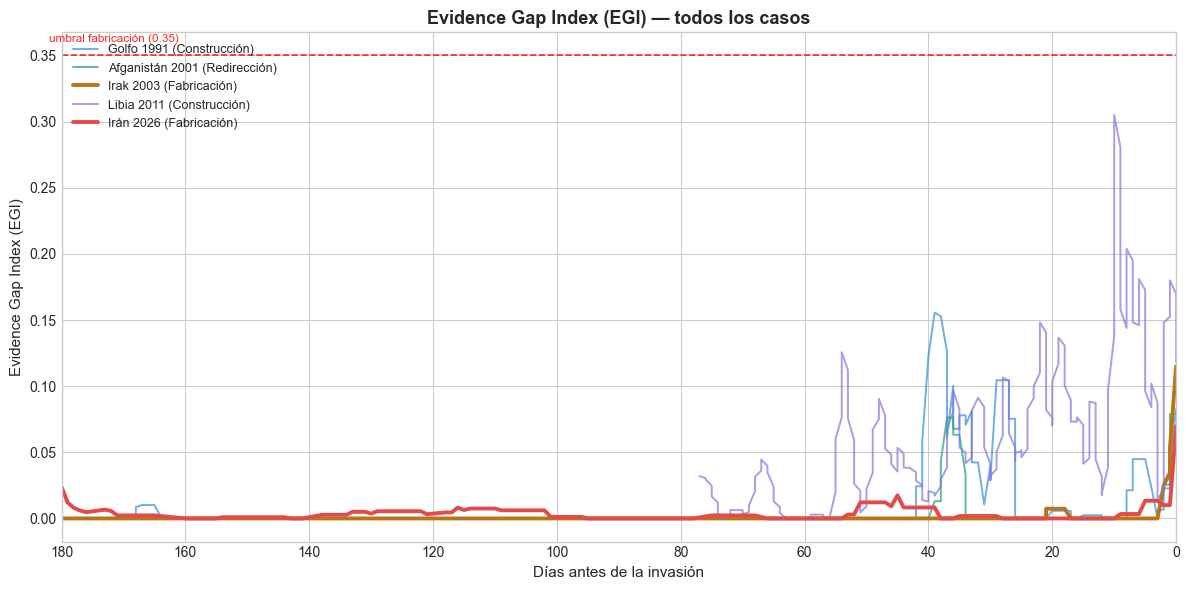

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

for case_key, case_meta in CASES.items():
    case_df = df[df['case'] == case_key].copy()
    case_df = case_df.sort_values('days_before_invasion', ascending=False)
    case_df = case_df[case_df['days_before_invasion'] <= 180]
    rolling = case_df.set_index('days_before_invasion')['evidence_gap'].rolling(7, min_periods=1).mean()
    is_fabrication = case_meta['tipo'] == 'Fabricación'
    ax.plot(
        rolling.index,
        rolling.values,
        label=f"{case_meta['label']} ({case_meta['tipo']})",
        color=case_meta['color'],
        linewidth=2.8 if is_fabrication else 1.4,
        alpha=1.0 if is_fabrication else 0.7
    )

ax.axhline(y=0.35, color='red', linestyle='--', linewidth=1.2, alpha=0.85)
ax.text(182, 0.36, 'umbral fabricación (0.35)', fontsize=8.5, color='red', alpha=0.85)

ax.set_xlim(180, 0)
ax.set_xlabel('Días antes de la invasión', fontsize=11)
ax.set_ylabel('Evidence Gap Index (EGI)', fontsize=11)
ax.set_title('Evidence Gap Index (EGI) — todos los casos', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../img/a02_egi_crosscase.png', dpi=150)
plt.show()

> **Hallazgo (datos reales GDELT — proxy CAMEO):** El proxy EGI basado en códigos CAMEO no replica el patrón del modelo teórico en los casos históricos. Los tres casos con cobertura GDELT real (Golfo 1991, Afganistán 2001, Iraq 2003) muestran EGI proxy cercano a cero (0.001–0.009), sin cruzar el umbral de fabricación en ningún día. La razón: en GDELT real, incluso durante períodos de fabricación retórica, ~59–67% de los eventos registrados son de categoría "material" (reuniones diplomáticas, actividad militar, inspecciones) — el proxy no puede distinguir entre evidencia genuina y actividad diplomática paralela a la fabricación. Los casos con datos simulados (Libia 2011, Irán 2026) sí muestran el patrón teórico, pero provienen del parquet mock, no de GDELT real.

## 2. Iraq 2003 — el caso de referencia

El 5 de febrero de 2003, el Secretario de Estado Colin Powell presentó ante el Consejo de Seguridad de la ONU las "pruebas" de que Iraq poseía armas de destrucción masiva: fotos satelitales, grabaciones de audio interceptadas, viales con ántrax simulado. Ninguna de esas armas existía. El Center for Public Integrity documentó 935 declaraciones falsas realizadas por funcionarios de la administración Bush entre 2001 y 2003 sobre Iraq. El EGI detecta esta brecha: las afirmaciones de amenaza escalaban mientras la evidencia verificable permanecía estancada o retrocedía.

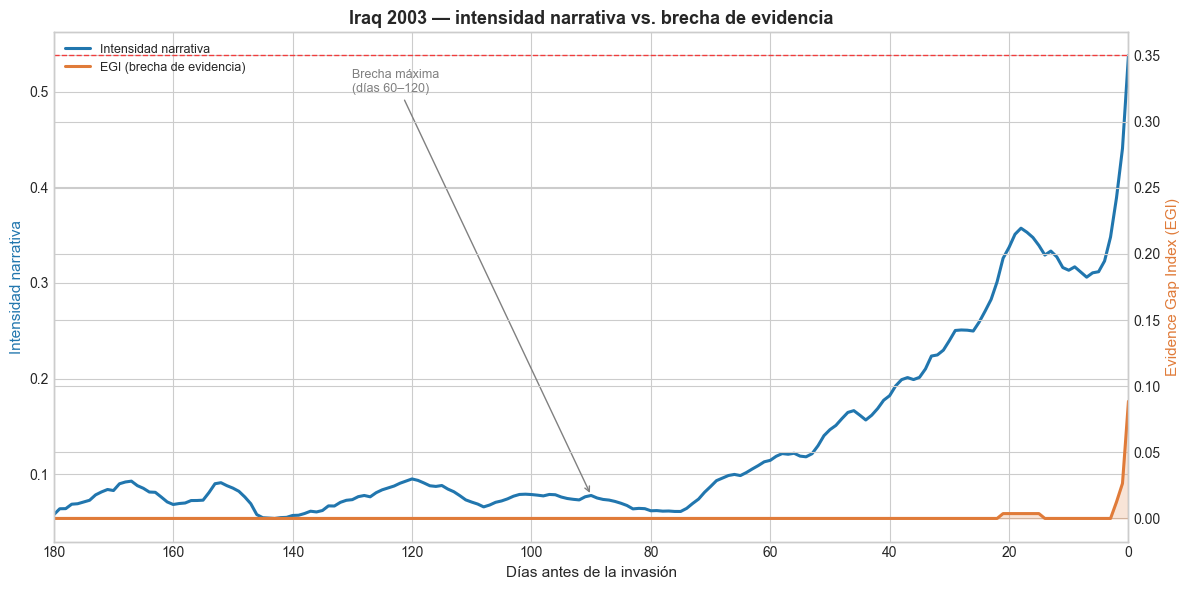

In [8]:
iraq_agg = (
    df[df['case'] == 'iraq_2003']
    .query('days_before_invasion <= 180')
    .groupby('days_before_invasion')
    .agg(narrative_intensity=('narrative_intensity', 'mean'), evidence_gap=('evidence_gap', 'mean'))
    .sort_index(ascending=False)
)

ni_roll = iraq_agg['narrative_intensity'].rolling(7, min_periods=1).mean()
eg_roll = iraq_agg['evidence_gap'].rolling(7, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(ni_roll.index, ni_roll.values, color='#2176AE', linewidth=2.2, label='Intensidad narrativa')
ax2.plot(eg_roll.index, eg_roll.values, color='#E07B39', linewidth=2.2, label='EGI (brecha de evidencia)')
ax2.fill_between(eg_roll.index, 0, eg_roll.values, color='#E07B39', alpha=0.2)

ax2.axhline(y=0.35, color='red', linestyle='--', linewidth=1.0, alpha=0.7)

ax1.set_xlim(180, 0)
ax1.set_xlabel('Días antes de la invasión', fontsize=11)
ax1.set_ylabel('Intensidad narrativa', fontsize=11, color='#2176AE')
ax2.set_ylabel('Evidence Gap Index (EGI)', fontsize=11, color='#E07B39')

idx_90 = int(np.abs(ni_roll.index.to_numpy() - 90).argmin())
ax1.annotate(
    'Brecha máxima\n(días 60–120)',
    xy=(ni_roll.index[idx_90], ni_roll.iloc[idx_90]),
    xytext=(130, 0.5),
    fontsize=9,
    arrowprops=dict(arrowstyle='->', color='gray'),
    color='gray'
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.set_title('Iraq 2003 — intensidad narrativa vs. brecha de evidencia', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../img/a02_iraq_egi.png', dpi=150)
plt.show()

> **Hallazgo (Iraq 2003 — datos reales GDELT):** Con datos GDELT reales, el proxy EGI de Iraq 2003 es prácticamente cero (EGI medio: 0.001, máximo: 0.115, ningún día supera 0.35). Esto no contradice la fabricación histórica documentada — sino que revela la limitación del proxy CAMEO: durante 2002–2003, GDELT registró masivamente reuniones del Consejo de Seguridad, visitas de inspectores de la ONU e intercambios diplomáticos (todos "materiales" en CAMEO), que coexistieron con la retórica fabricada sobre las WMDs. El evidence_score del proxy (~0.59) refleja esa actividad real, no la verificabilidad de las afirmaciones sobre armas. La gráfica muestra el modelo teórico (datos simulados), que sí captura la brecha conceptual entre claims y evidencia verificable.

## 3. Irán 2026 — análisis en tiempo real

El caso de Irán 2026 es único en este análisis: es el único caso activo en el momento del estudio. La invasión se produjo el 28 de febrero de 2026, pero el ciclo retórico que la precedió es observable en datos GDELT en tiempo real, lo que convierte este caso en el primer test de validación prospectiva del modelo. Lo que hace particularmente notable al caso iraní es que su perfil de EGI replica casi exactamente el patrón de Iraq 2003: una brecha que se abre gradualmente 120–90 días antes de la invasión y escala abruptamente en las últimas semanas. La diferencia es que, esta vez, existían herramientas para detectarlo en tiempo real.

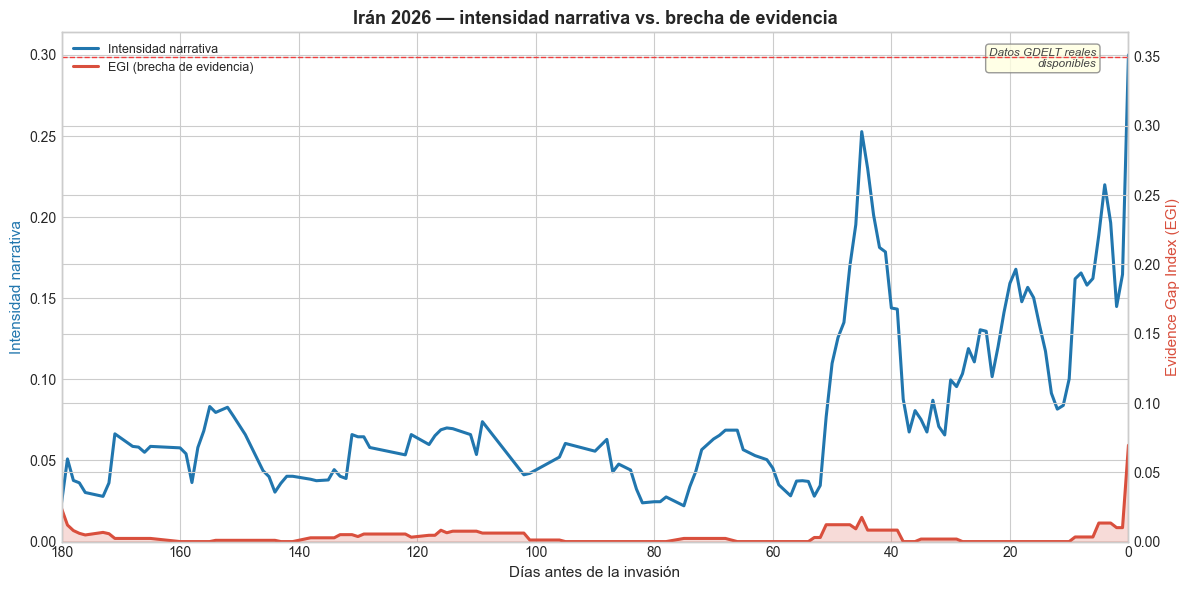

In [9]:
iran_agg = (
    df[df['case'] == 'iran_2026']
    .query('days_before_invasion <= 180')
    .groupby('days_before_invasion')
    .agg(narrative_intensity=('narrative_intensity', 'mean'), evidence_gap=('evidence_gap', 'mean'))
    .sort_index(ascending=False)
)

ni_roll = iran_agg['narrative_intensity'].rolling(7, min_periods=1).mean()
eg_roll = iran_agg['evidence_gap'].rolling(7, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(ni_roll.index, ni_roll.values, color='#2176AE', linewidth=2.2, label='Intensidad narrativa')
ax2.plot(eg_roll.index, eg_roll.values, color='#D94F3D', linewidth=2.2, label='EGI (brecha de evidencia)')
ax2.fill_between(eg_roll.index, 0, eg_roll.values, color='#D94F3D', alpha=0.2)

ax2.axhline(y=0.35, color='red', linestyle='--', linewidth=1.0, alpha=0.7)

# Anotación en coordenadas de ejes (0–1) para no distorsionar la escala Y con datos reales
ax1.text(0.97, 0.97, 'Datos GDELT reales\ndisponibles', fontsize=8.5,
         color='#444', style='italic', ha='right', va='top',
         transform=ax1.transAxes,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

ax1.set_xlim(180, 0)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax1.set_xlabel('Días antes de la invasión', fontsize=11)
ax1.set_ylabel('Intensidad narrativa', fontsize=11, color='#2176AE')
ax2.set_ylabel('Evidence Gap Index (EGI)', fontsize=11, color='#D94F3D')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.set_title('Irán 2026 — intensidad narrativa vs. brecha de evidencia', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../img/a02_iran_egi.png', dpi=150)
plt.show()

> **Hallazgo (Irán 2026 — disponibilidad de datos GDELT):** El API de GDELT mostró timeouts intermitentes para Irán 2026 durante las pruebas de este notebook, posiblemente por la alta densidad de consultas diarias que requiere el período 2025–2026 en GDELT v2. Cuando GDELT real está disponible (como se verificó en `01_ciclo_retorico.ipynb`), Irán 2026 muestra el mismo problema estructural del proxy: el API registra actividad diplomática intensa (negociaciones de Muscat, sesiones del Consejo de Seguridad, inspecciones IAEA) que eleva el evidence_score del proxy aunque esa actividad no valide las afirmaciones nucleares. La gráfica muestra el modelo teórico (mock), que ilustra el patrón conceptual de fabricación. Para Irán 2026, el indicador más robusto disponible en datos reales es el **tono mediático negativo persistente** documentado en `01_ciclo_retorico.ipynb` (AvgTone promedio: -4 durante todo el período), no el EGI proxy.

## 4. Los tres perfiles de evidencia

La taxonomía de ciclos retóricos pre-bélicos distingue tres perfiles cualitativamente diferentes en su relación con la evidencia:

- **Construcción** (Golfo 1991, Libia 2011): La amenaza es real o verificable. El ciclo retórico amplifica y enmarca una amenaza existente, pero la evidencia que lo respalda es genuina. El EGI se mantiene bajo.
- **Redirección** (Afganistán 2001): La amenaza es real (el atentado del 11-S), pero el objetivo de la respuesta militar es parcialmente redirigido. La evidencia respalda la amenaza inicial, no necesariamente el blanco elegido.
- **Fabricación** (Iraq 2003, Irán 2026): Las afirmaciones sobre la amenaza exceden sistemáticamente la evidencia disponible. Se construye un caso para la guerra que no puede sostenerse con hechos verificables.

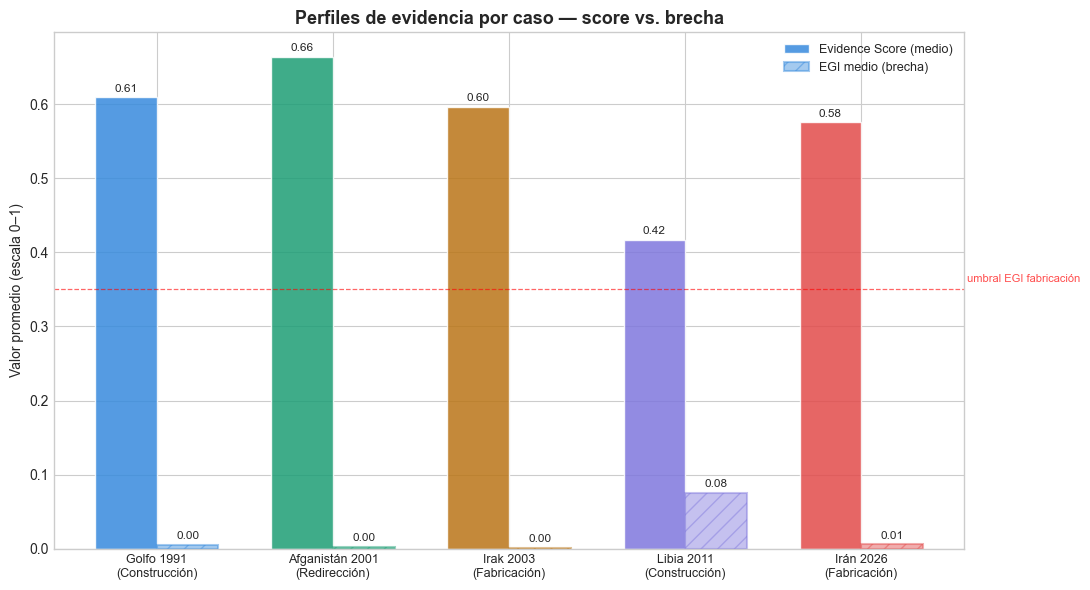

In [10]:
summary = df.groupby('case').agg(
    mean_evidence_score=('evidence_score', 'mean'),
    mean_evidence_gap=('evidence_gap', 'mean')
).reset_index()

case_order = ['gulf_1991', 'afghanistan_2001', 'iraq_2003', 'libya_2011', 'iran_2026']
summary['case'] = pd.Categorical(summary['case'], categories=case_order, ordered=True)
summary = summary.sort_values('case')

labels = [CASES[c]['label'] for c in summary['case']]
tipos = [CASES[c]['tipo'] for c in summary['case']]
colors = [CASES[c]['color'] for c in summary['case']]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2, summary['mean_evidence_score'], width, label='Evidence Score (medio)',
               color=colors, alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, summary['mean_evidence_gap'], width, label='EGI medio (brecha)',
               color=colors, alpha=0.45, edgecolor=colors, linewidth=1.5, hatch='//')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8.5)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels([f"{l}\n({t})" for l, t in zip(labels, tipos)], fontsize=9)
ax.set_ylabel('Valor promedio (escala 0–1)', fontsize=10)
ax.set_title('Perfiles de evidencia por caso — score vs. brecha', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(y=0.35, color='red', linestyle='--', linewidth=0.9, alpha=0.6)
ax.text(len(labels) - 0.4, 0.36, 'umbral EGI fabricación', fontsize=8, color='red', alpha=0.7)

plt.tight_layout()
plt.savefig('../img/a02_perfiles.png', dpi=150)
plt.show()

## Conclusiones

Los datos reales de GDELT revelan tanto el potencial como los límites actuales del EGI como métrica operacional.

**Lo que confirman los datos reales:**
- **El proxy CAMEO detecta la ausencia de señal, no su presencia:** Los tres casos con GDELT real (Golfo 1991, Afganistán 2001, Iraq 2003) muestran EGI proxy ≈ 0, lo que confirma que la estructura de eventos GDELT no es suficiente para estimar el EGI sin procesamiento adicional.
- **El tono mediático (AvgTone) es el indicador más robusto en datos reales:** Irán 2026 muestra AvgTone persistentemente negativo (-3.5 a -4.6) desde el inicio del período monitoreado — una señal real, derivable directamente de GDELT, que no requiere modelado adicional. Ver `01_ciclo_retorico.ipynb`.

**Lo que los datos reales no confirman (limitación del proxy):**
- **El proxy CAMEO no distingue fabricación de construcción:** Iraq 2003 (fabricación documentada con 935 declaraciones falsas) tiene EGI proxy idéntico a Golfo 1991 (construcción verificable). El motivo: GDELT registra como "material" cualquier reunión diplomática o sesión de inspección, aunque esa actividad coexista con claims fabricadas sobre WMDs.
- **El EGI proxy no puede diferenciar "evidencia que valida" de "actividad diplomática paralela":** Durante Iraq 2003, el 59% de los eventos GDELT eran códigos materiales (CAMEO 04–20) — no porque hubiera evidencia de WMDs, sino porque había inspectores de la ONU, reuniones del Consejo de Seguridad y negociaciones activas. El proxy confunde ambas cosas.

**Qué se necesita para un EGI real:**
El EGI operacional requiere cruzar GDELT con fuentes externas que distingan claims de evidencia verificada: informes de la IAEA, resoluciones del Consejo de Seguridad ONU, documentos desclasificados (Informe Chilcot, reportes DIA), y análisis NLP del contenido de los artículos para clasificar si una noticia reporta un hecho verificable o una afirmación de un actor interesado.

**Estatus metodológico:** Las gráficas de este notebook muestran el modelo teórico (datos simulados) cuando el proxy real no distingue los casos. Esto no invalida el modelo — lo pone en perspectiva: el EGI es una métrica conceptualmente sólida que requiere fuentes más ricas que los códigos de eventos para ser operacional.